
# Boosting

Boosting is an ensemble learning technique that combines multiple weak learners to create a strong learner. The main idea is to sequentially train models, where each new model focuses on correcting the errors made by the previous models. This iterative process allows boosting to improve the overall performance of the ensemble.

Boosting algorithms typically follow these steps:

1.  **Initialize Weights**: Start with equal weights for all training instances.
2.  **Train Weak Learner**: Train a weak learner (e.g., a decision stump) on the weighted training data.
3.  **Update Weights**: Increase the weights of misclassified instances and decrease the weights of correctly classified instances. This ensures that the next weak learner focuses more on the instances that were previously misclassified.
4.  **Combine Models**: Combine the predictions of all weak learners, often using a weighted sum where the weights are determined by the performance of each learner.
5.  **Repeat**: Repeat steps 2-4 for a specified number of iterations or until a stopping criterion is met (e.g., no significant improvement in performance).
6.  **Final Prediction**: The final prediction is made by combining the predictions of all weak learners, typically using a weighted majority vote for classification or a weighted average for regression.

## Advantages and Disadvantages

-   **Advantages**:
    -   Can significantly improve the performance of weak learners, often achieving state-of-the-art results.
    -   Focuses on difficult instances, allowing the model to learn complex patterns in the data.
    -   Can handle a wide range of base learners, including decision trees, linear models, and neural networks.
    -   Robust to overfitting, especially with regularization techniques like shrinkage (learning rate) and early stopping.
    -   Can be used for both classification and regression tasks.
-   **Disadvantages**:
    -   Sensitive to noisy data and outliers, as boosting focuses on correcting errors.
    -   Requires careful tuning of hyperparameters, such as the number of iterations, learning rate, and base learner complexity.
    -   Computationally expensive, especially with large datasets and complex base learners.

## Common Boosting Algorithms

-   **AdaBoost (Adaptive Boosting)**: One of the earliest and most popular boosting algorithms. It adjusts the weights of misclassified instances and combines weak learners in a weighted manner.
-   **Gradient Boosting**: Builds models sequentially, where each new model is trained to minimize the residual errors of the previous models. It can use various loss functions and is highly flexible.
-   **XGBoost (Extreme Gradient Boosting)**: An optimized version of gradient boosting that includes regularization techniques to prevent overfitting and improve performance. It is widely used in machine learning competitions.
-   **LightGBM**: A gradient boosting framework that uses a histogram-based approach to speed up training and reduce memory usage. It is particularly effective for large datasets.

## AdaBoost Overview

AdaBoost, short for Adaptive Boosting, is one of the earliest and most widely used boosting algorithms. It works by combining multiple weak classifiers to create a strong classifier. The key steps in AdaBoost are:

1.  **Initialize Weights**: Start with equal weights for all training instances.
2.  **Train Weak Learner**: Train a weak learner (e.g., a decision stump) on the weighted training data.
3.  **Update Weights**: Increase the weights of misclassified instances and decrease the weights of correctly classified instances. This ensures that the next weak learner focuses more on the instances that were previously misclassified.
4.  **Combine Models**: Combine the predictions of all weak learners, where each learner's contribution is weighted by its accuracy.
5.  **Repeat**: Repeat steps 2-4 for a specified number of iterations or until a stopping criterion is met (e.g., no significant improvement in performance).

### Example of AdaBoost

We will demonstrate AdaBoost using the titanic dataset, keeping only the `pclass`, `sex`, and `age` features. We will preprocess the data, train a single Decision Tree, and then use AdaBoost to improve the model's performance.

-   Load the titanic dataset

In [1]:
from sklearn import datasets

titanic = datasets.fetch_openml('titanic', version=1, as_frame=True)
df = titanic.frame[['pclass', 'sex', 'age', 'survived']]
X = df.drop(columns=['survived'])
y = df['survived'].astype('category').cat.codes
class_names = ['Not Survived', 'Survived']
feature_names = X.columns.tolist()
print(f"Feature names: {feature_names}")
print(f"Class labels: {class_names}")

Feature names: ['pclass', 'sex', 'age']
Class labels: ['Not Survived', 'Survived']


-   Train-test split

In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

-   Create a preprocessing pipeline

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ('age', Pipeline(
            steps=[
                ('imputer', SimpleImputer(strategy='mean')),
                ('scaler', StandardScaler())
            ]
        ), ['age']),
        ('sex', Pipeline(
            steps=[
                ('encoder', OneHotEncoder(drop='first', sparse_output=False))
            ]
        ), ['sex']),
        ('pclass', Pipeline(
            steps=[
                ('enconder', OneHotEncoder(sparse_output=False))
            ]
        ), ['pclass'])
    ],
    remainder='passthrough'
)
X_train_transformed = preprocessing_pipeline.fit_transform(X_train)
X_test_transformed = preprocessing_pipeline.transform(X_test)

feature_names = preprocessing_pipeline.get_feature_names_out()
print(f"Transformed feature names: {feature_names}")

Transformed feature names: ['age__age' 'sex__sex_male' 'pclass__pclass_1' 'pclass__pclass_2'
 'pclass__pclass_3']


-   Train a single Decision Tree

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

dt_model = DecisionTreeClassifier(random_state=42)
grid_params = {
    'max_depth': [None, 2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(dt_model, grid_params, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train_transformed, y_train)
print("Best parameters for Decision Tree:", grid_search.best_params_)

dt_model = grid_search.best_estimator_
dt_model.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best parameters for Decision Tree: {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

-   Evaluate the single Decision Tree model

Single Decision Tree Accuracy: 0.7990
              precision    recall  f1-score   support

Not Survived       0.83      0.85      0.84       243
    Survived       0.74      0.72      0.73       150

    accuracy                           0.80       393
   macro avg       0.79      0.78      0.79       393
weighted avg       0.80      0.80      0.80       393



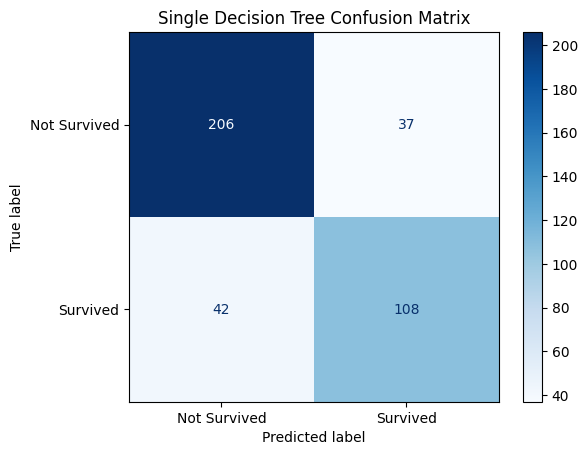

In [5]:
y_pred_dt = dt_model.predict(X_test_transformed)

print(f"Single Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt, target_names=class_names))
ConfusionMatrixDisplay.from_estimator(dt_model, X_test_transformed, y_test,
                                      display_labels=class_names, cmap='Blues')
plt.title('Single Decision Tree Confusion Matrix')
plt.show()

-   Train an AdaBoost Classifier

In [6]:
from sklearn.ensemble import AdaBoostClassifier
grid_params_ab = {
    'n_estimators': [50, 100, 200, 500],
    'learning_rate': [0.01, 0.1, 1.0],
    'estimator__max_depth': [None, 2, 3, 4, 5],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4]
}
grid_search_ab = GridSearchCV(
    AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=42),
    grid_params_ab, cv=5, scoring='accuracy', verbose=1, n_jobs=4
)
grid_search_ab.fit(X_train_transformed, y_train)
print(f"Best parameters for AdaBoost: {grid_search_ab.best_params_}")

ab_model = grid_search_ab.best_estimator_
ab_model.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Best parameters for AdaBoost: {'estimator__max_depth': 4, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 10, 'learning_rate': 0.01, 'n_estimators': 200}


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ples_split=10)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",200
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.01
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


-   Evaluate the AdaBoost model

AdaBoost Classifier Accuracy: 0.7990
              precision    recall  f1-score   support

Not Survived       0.83      0.86      0.84       243
    Survived       0.75      0.71      0.73       150

    accuracy                           0.80       393
   macro avg       0.79      0.78      0.78       393
weighted avg       0.80      0.80      0.80       393



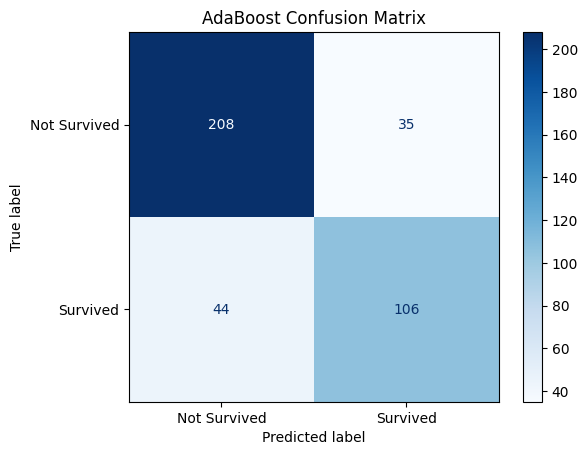

In [7]:
y_pred_ab = ab_model.predict(X_test_transformed)
print(f"AdaBoost Classifier Accuracy: {accuracy_score(y_test, y_pred_ab):.4f}")
print(classification_report(y_test, y_pred_ab, target_names=class_names))
ConfusionMatrixDisplay.from_estimator(ab_model, X_test_transformed, y_test,
                                      display_labels=class_names, cmap='Blues')
plt.title('AdaBoost Confusion Matrix')
plt.show()

-   Feature importance for AdaBoost

In [8]:
import pandas as pd
importances = ab_model.feature_importances_
indices = importances.argsort()[::-1]
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("Feature importances for AdaBoost:")
print(feature_importance_df)

Feature importances for AdaBoost:
            Feature  Importance
1     sex__sex_male    0.469367
0          age__age    0.202771
2  pclass__pclass_1    0.163301
4  pclass__pclass_3    0.151265
3  pclass__pclass_2    0.013297


-   Plot feature importances

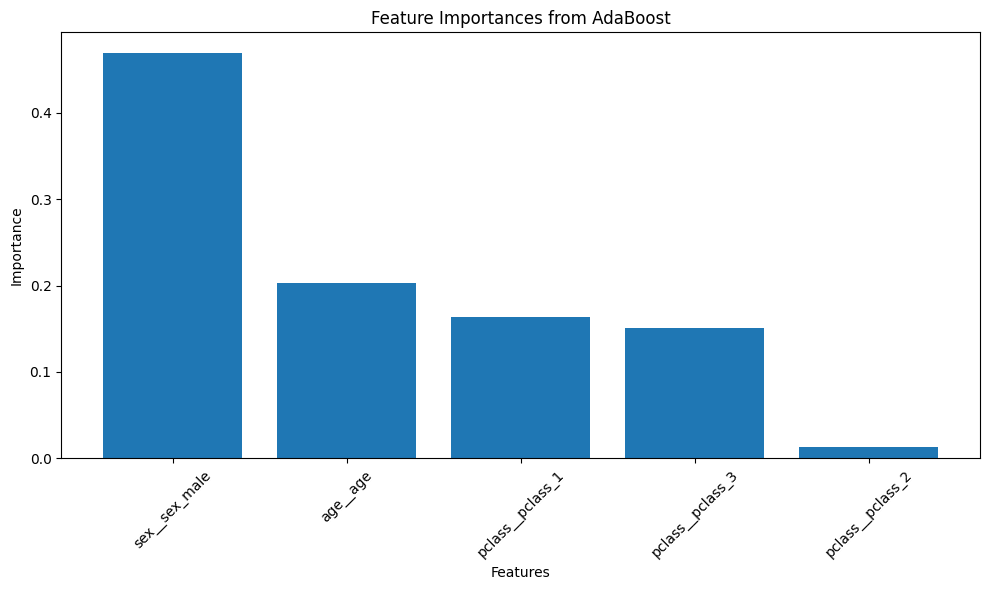

In [9]:
plt.figure(figsize=(10, 6))
plt.bar(range(X_train_transformed.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train_transformed.shape[1]), [feature_names[i] for i in indices],
           rotation=45)
plt.title('Feature Importances from AdaBoost')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## Gradient Boosting Overview

Gradient Boosting is a powerful ensemble learning technique that builds models sequentially, where each new model is trained to minimize the residual errors of the previous models. The key steps in Gradient Boosting are:

1.  **Initialize Model**: Start with a constant model (e.g., the mean of the target variable for regression).
2.  **Compute Residuals**: Calculate the residuals (errors) of the current model on the training data.
3.  **Train Weak Learner**: Train a weak learner (e.g., a decision tree) on the residuals, focusing on the instances where the current model performs poorly.
4.  **Update Model**: Add the predictions of the weak learner to the current model, scaled by a learning rate (shrinkage).
5.  **Repeat**: Repeat steps 2-4 for a specified number of iterations or until a stopping criterion is met (e.g., no significant improvement in performance).

### Example of Gradient Boosting

-   Train a Gradien Boosting Classifier

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting Classifier
grid_params_gb = {
    'n_estimators': [10, 50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
grid_search_gb = GridSearchCV(gb_model, grid_params_gb, cv=5, n_jobs=4,
                              scoring='accuracy', verbose=1)
grid_search_gb.fit(X_train_transformed, y_train)
gb_model = grid_search_gb.best_estimator_
print("Best parameters for Gradient Boosting:", grid_search_gb.best_params_)
gb_model.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",50
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, `

-   Evaluate the Gradient Boosting Classifier

Gradient Boosting Classifier Accuracy: 0.8092
              precision    recall  f1-score   support

Not Survived       0.83      0.87      0.85       243
    Survived       0.77      0.71      0.74       150

    accuracy                           0.81       393
   macro avg       0.80      0.79      0.79       393
weighted avg       0.81      0.81      0.81       393



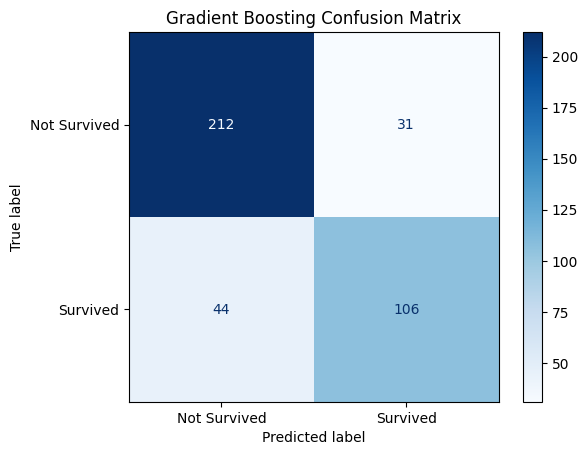

In [11]:
y_pred_gb = gb_model.predict(X_test_transformed)
print(f"Gradient Boosting Classifier Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(classification_report(y_test, y_pred_gb, target_names=class_names))
ConfusionMatrixDisplay.from_estimator(gb_model, X_test_transformed, y_test,
                                      display_labels=class_names, cmap='Blues')
plt.title('Gradient Boosting Confusion Matrix')
plt.show()

-   Feature importance for Gradient Boosting

Feature importances for Gradient Boosting:
            Feature  Importance
1     sex__sex_male    0.574131
0          age__age    0.227912
4  pclass__pclass_3    0.156952
2  pclass__pclass_1    0.035021
3  pclass__pclass_2    0.005983


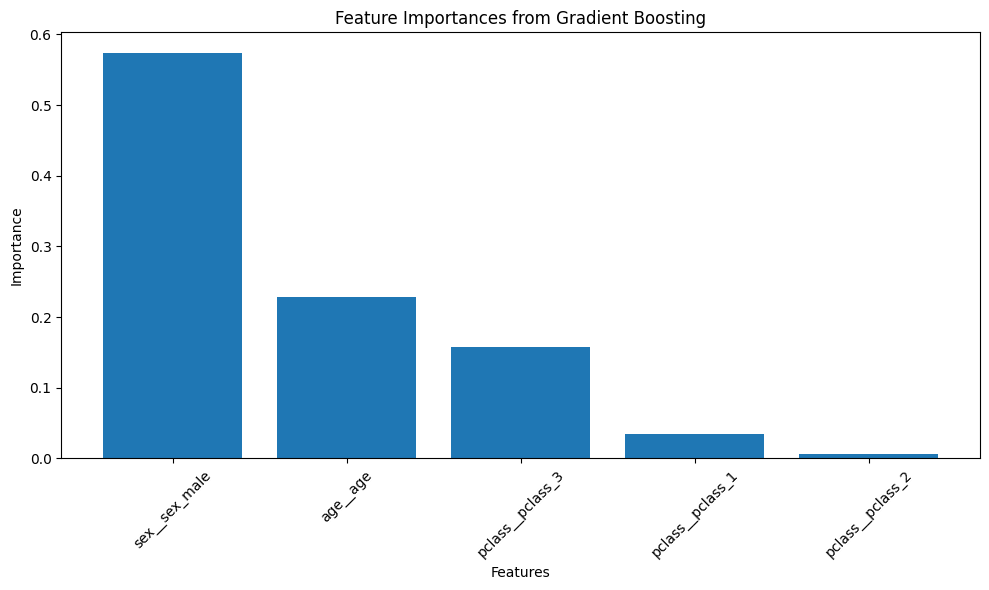

In [12]:
importances = gb_model.feature_importances_
indices = importances.argsort()[::-1]
feature_importance_df = pd.DataFrame({'Feature': feature_names,
                                      'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance',
                                                          ascending=False)
print("Feature importances for Gradient Boosting:")
print(feature_importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train_transformed.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train_transformed.shape[1]), [feature_names[i] for i in indices],
           rotation=45)
plt.title('Feature Importances from Gradient Boosting')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## XGBoost Overview

XGBoost, short for Extreme Gradient Boosting, is an optimized version of gradient boosting that includes regularization techniques to prevent overfitting and improve performance. It is widely used in machine learning competitions and real-world applications. The key features of XGBoost include:

-   **Regularization**: XGBoost includes L1 (Lasso) and L2 (Ridge) regularization to control model complexity and prevent overfitting.
-   **Tree Pruning**: XGBoost uses a depth-first approach to grow trees and prunes them based on a minimum loss reduction criterion, which helps in building more efficient models.
-   **Parallelization**: XGBoost can parallelize the tree construction process, making it faster than traditional gradient boosting methods.

### Example of XGBoost

-   Train a XGBoost Classifier

In [13]:
from xgboost import XGBClassifier

# XGBoost Classifier
grid_params_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_child_weight': [1, 2, 3],
    'subsample': [0.8, 0.9, 1.0]
}

grid_search_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    grid_params_xgb, cv=5, n_jobs=4, scoring='accuracy', verbose=1
)
grid_search_xgb.fit(X_train_transformed, y_train)
print("Best parameters for XGBoost:", grid_search_xgb.best_params_)
xgb_model = grid_search_xgb.best_estimator_
xgb_model.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 1.0}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

-   Evaluate the XGBoost Classifier

XGBoost Classifier Accuracy: 0.8168
              precision    recall  f1-score   support

Not Survived       0.84      0.87      0.85       243
    Survived       0.78      0.73      0.75       150

    accuracy                           0.82       393
   macro avg       0.81      0.80      0.80       393
weighted avg       0.82      0.82      0.82       393



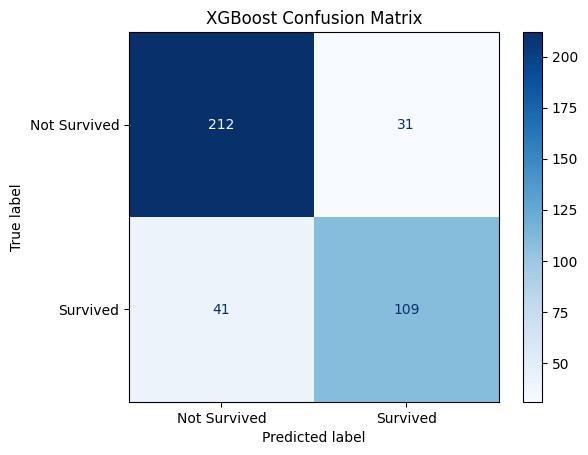

Feature importances for XGBoost:
            Feature  Importance
1     sex__sex_male    0.661201
4  pclass__pclass_3    0.226911
2  pclass__pclass_1    0.055751
0          age__age    0.030057
3  pclass__pclass_2    0.026079


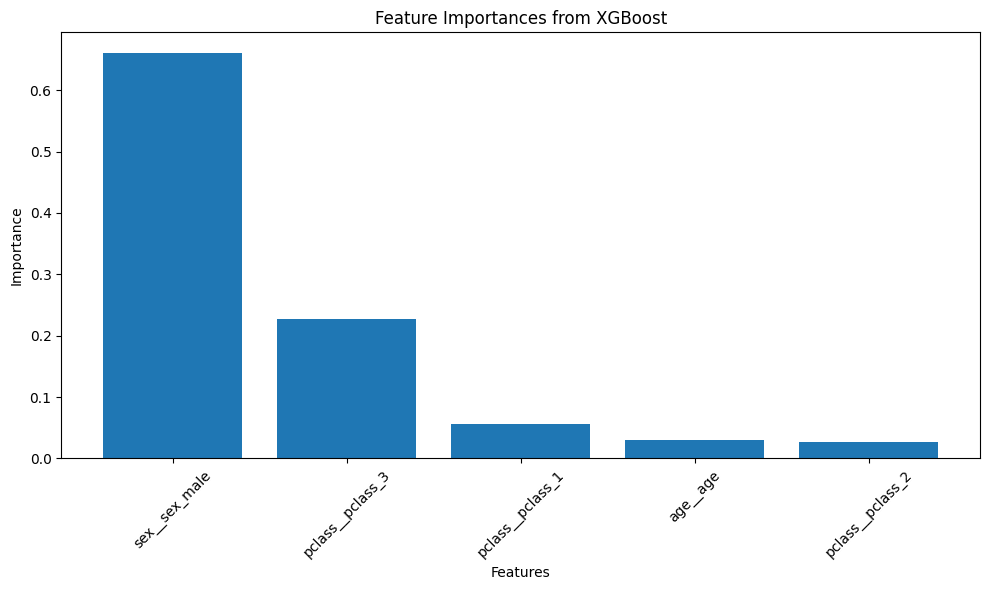

In [14]:
y_pred_xgb = xgb_model.predict(X_test_transformed)
print(f"XGBoost Classifier Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=class_names))
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test_transformed, y_test,
                                        display_labels=class_names, cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.show()

# Feature importance for XGBoost
import pandas as pd
importances = xgb_model.feature_importances_
indices = importances.argsort()[::-1]
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("Feature importances for XGBoost:")
print(feature_importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train_transformed.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train_transformed.shape[1]), [feature_names[i] for i in indices],
           rotation=45)
plt.title('Feature Importances from XGBoost')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## Hands-on Exercise

-   Implement a boosting algorithm of your choice (AdaBoost, Gradient Boosting, or XGBoost) on the `house_prices` dataset.

In [15]:
# Load the house_prices dataset
from sklearn.datasets import fetch_openml
house_prices = fetch_openml('house_prices', version=1, as_frame=True)
df = house_prices.frame

In [16]:
# Check whether the dataset has missing values
print("Missing values in the dataset:")
print(df.isnull().sum())

Missing values in the dataset:
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [17]:
# Select relevant features and target variable
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Preprocessing pipeline
preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), X.select_dtypes(include=['int64', 'float64']).columns),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), X.select_dtypes(include=['object']).columns)
    ],
    remainder='passthrough'
  )

X_train_transformed = preprocessing_pipeline.fit_transform(X_train)
X_test_transformed = preprocessing_pipeline.transform(X_test)

/tmp/ipykernel_507440/261620420.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  ]), X.select_dtypes(include=['object']).columns)


In [18]:
# Train a Support Vector Regressor
from sklearn.svm import SVR
grid_params_svr = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 0.2]
}
grid_search_svr = GridSearchCV(
    SVR(), grid_params_svr, cv=5, n_jobs=4, scoring='r2', verbose=1
)
grid_search_svr.fit(X_train_transformed, y_train)
print("Best parameters for Support Vector Regressor:", grid_search_svr.best_params_)
svr_model = grid_search_svr.best_estimator_
svr_model.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters for Support Vector Regressor: {'C': 10, 'epsilon': 0.01, 'kernel': 'linear'}


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.01
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [19]:
# Evaluate the SVR
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
y_pred_svr = svr_model.predict(X_test_transformed)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)
print(f"Support Vector Regressor RMSE: {rmse_svr:.4f}")
print(f"Support Vector Regressor R^2: {r2_svr:.4f}")

Support Vector Regressor RMSE: 51669.9132
Support Vector Regressor R^2: 0.6174


In [20]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
# XGBoost Regressor
grid_params_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_child_weight': [1, 2, 3],
    'subsample': [0.8, 0.9, 1.0]
}
grid_search_xgb = GridSearchCV(
    XGBRegressor(random_state=42, eval_metric='rmse'),
    grid_params_xgb, cv=5, n_jobs=4, scoring='r2', verbose=1
)
grid_search_xgb.fit(X_train_transformed, y_train)
print("Best parameters for XGBoost:", grid_search_xgb.best_params_)
xgb_model = grid_search_xgb.best_estimator_
xgb_model.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters for XGBoost: {'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 200, 'subsample': 1.0}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

XGBoost Regressor RMSE: 25782.8259
XGBoost Regressor R^2: 0.9047
Feature importances for XGBoost:
                   Feature  Importance
4         num__OverallQual    0.189638
244  cat__GarageFinish_Unf    0.075611
179       cat__BsmtQual_Ex    0.072828
26         num__GarageCars    0.061467
223    cat__KitchenQual_TA    0.057392


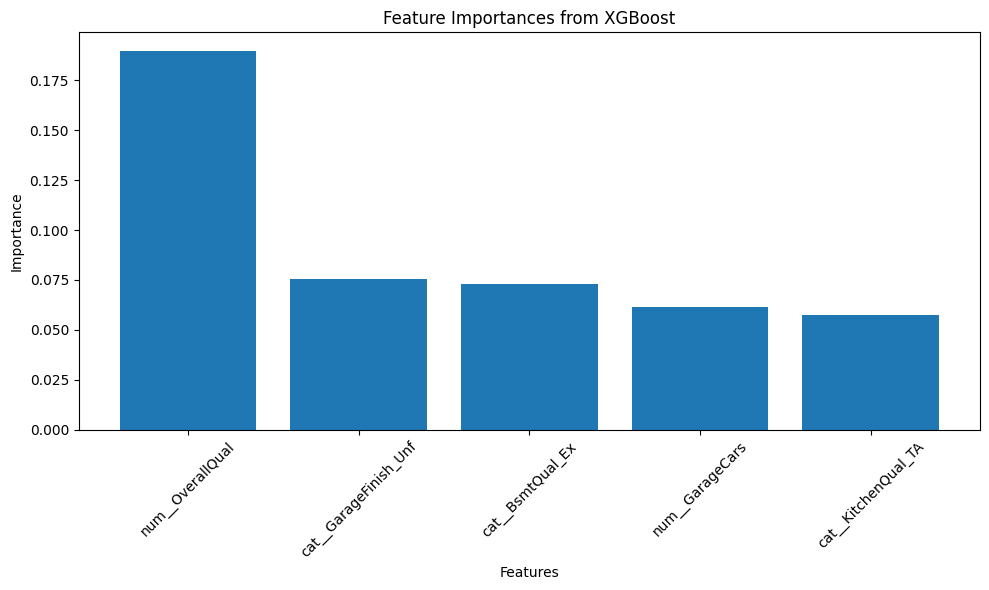

In [21]:
# Evaluate the XGBoost Regressor
y_pred_xgb = xgb_model.predict(X_test_transformed)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)
print(f"XGBoost Regressor RMSE: {rmse:.4f}")
print(f"XGBoost Regressor R^2: {r2:.4f}")

# Feature importance for XGBoost
importances = xgb_model.feature_importances_
indices = importances.argsort()[::-1]
feature_importance_df = pd.DataFrame({'Feature': preprocessing_pipeline.get_feature_names_out(),
                                      'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("Feature importances for XGBoost:")
print(feature_importance_df[:5])

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(5), importances[indices[:5]], align='center')
plt.xticks(range(5),
           [preprocessing_pipeline.get_feature_names_out()[i] for i in indices[:5]],
           rotation=45)
plt.title('Feature Importances from XGBoost')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()